In [4]:
import pandas as pd 
import numpy as np
import pandas as pd

In [5]:
np.random.seed(42)

# Generate X values
X = np.round(np.random.uniform(3.00, 9.80, 500), 2)


# Generate Y with a linear relationship
# Y = 1.0 + 0.9*X + noise
noise = np.random.normal(0, 0.25, 500)

Y = 1.0 + (0.9 * X) + noise

# Keep Y within range 3.00 to 10.00
Y = np.clip(Y, 3.00, 10.00)

# Round to 2 decimal places
Y = np.round(Y, 2)

# Create DataFrame
dataset = pd.DataFrame({
    'CGPA': X,
    'Packeg': Y
})

print(dataset.head())

   CGPA  Packeg
0  5.55    6.08
1  9.46    9.98
2  7.98    8.42
3  7.07    7.22
4  4.06    4.43


In [6]:
dataset.head()

,CGPA,Packeg
0,5.55,6.08
1,9.46,9.98
2,7.98,8.42
3,7.07,7.22
4,4.06,4.43


In [7]:
dataset.describe()

,CGPA,Packeg
count,500.000000,500.000000
mean,6.390340,6.752460
std,2.031174,1.861101
min,3.030000,3.380000
25%,4.637500,5.157500
50%,6.490000,6.820000
75%,8.142500,8.372500
max,9.750000,10.000000


In [8]:
dataset.isnull().sum()

CGPA      0
Packeg    0
dtype: int64

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

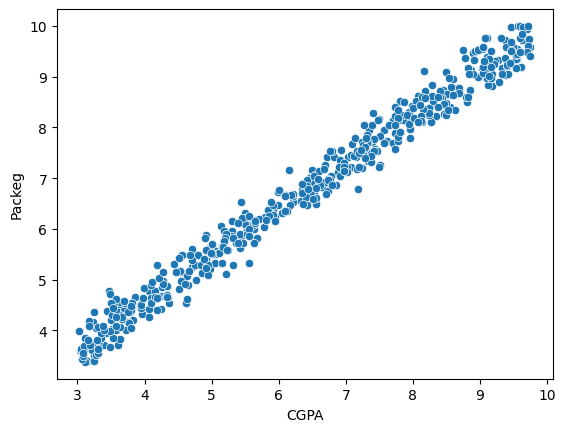

In [10]:
plt.Figure(figsize=(10,4))
sns.scatterplot(x="CGPA",y="Packeg",data=dataset)
plt.show()

In [11]:
#Now will split the indepentedn and Dependent variable 
#Based on Independent CGPA we are finding Packeg is dependent 

x = dataset[["CGPA"]]
y = dataset["Packeg"]
x.ndim,y.ndim

(2, 1)

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [13]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
lr = LinearRegression()
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.91]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['CGPA']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.9467
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [21]:
lr.predict([[5.60]])

d:\Data Science\.All_venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([6.03118686])

In [22]:
lr.score(x_test,y_test)*100

98.04301584400315

In [23]:
lr.coef_

array([0.90795126])

In [24]:
lr.intercept_

np.float64(0.9466598047242121)

In [29]:
y_prd = lr.predict(x)

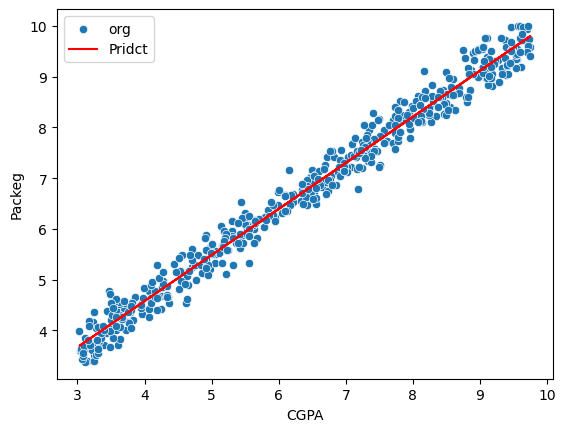

In [32]:
plt.Figure(figsize=(10,5))
sns.scatterplot(x="CGPA",y="Packeg",data=dataset,label ="org")
plt.plot(dataset["CGPA"],y_prd,c = "red",label = "Pridct")
plt.legend()
plt.show()